<a href="https://colab.research.google.com/github/Ansarss/Ai_learning_experiments/blob/main/Counterfactual_Analysis_of_a_Hypothetical_Minimum_Wage_Increase_on_Employment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Counterfactual Analysis of a Hypothetical Wage Increase on Employment

## Research Question

How would employment in the U.S. leisure and hospitality sector change under a hypothetical increase in wages, holding other modeled economic conditions constant?

## Objective

This project uses regression-based counterfactual analysis to estimate how employment in the U.S. leisure and hospitality sector might differ under hypothetical wage increases.

The analysis compares baseline employment predictions with counterfactual predictions generated by modifying the wage variable while keeping other explanatory variables unchanged.

Several hypothetical wage scenarios will be evaluated, including increases of 5%, 10%, 15%, and 20%.

# Data Collection and Initial Setup

In [1]:
# ============================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import statsmodels.api as sm

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================
# 2. LOAD DATA FROM FRED
# ============================================

# FRED CSV endpoints
employment_url = (
    "https://fred.stlouisfed.org/graph/fredgraph.csv?id=USLAH"
)

wage_url = (
    "https://fred.stlouisfed.org/graph/fredgraph.csv?id=CES7000000008"
)

# Load datasets
employment = pd.read_csv(employment_url)
wages = pd.read_csv(wage_url)

print("Employment data:")
display(employment.head())

print("\nWage data:")
display(wages.head())

Employment data:


,observation_date,USLAH
0,1939-01-01,1860
1,1939-02-01,1867
2,1939-03-01,1877
3,1939-04-01,1887
4,1939-05-01,1888



Wage data:


,observation_date,CES7000000008
0,1964-01-01,1.05
1,1964-02-01,1.06
2,1964-03-01,1.06
3,1964-04-01,1.07
4,1964-05-01,1.08


In [3]:
print("Employment shape:", employment.shape)
print("Wage shape:", wages.shape)

print("\nEmployment columns:")
print(employment.columns)

print("\nWage columns:")
print(wages.columns)

print("\nEmployment data types:")
print(employment.dtypes)

print("\nWage data types:")
print(wages.dtypes)

Employment shape: (1052, 2)
Wage shape: (752, 2)

Employment columns:
Index(['observation_date', 'USLAH'], dtype='object')

Wage columns:
Index(['observation_date', 'CES7000000008'], dtype='object')

Employment data types:
observation_date    object
USLAH                int64
dtype: object

Wage data types:
observation_date     object
CES7000000008       float64
dtype: object


In [4]:
# Rename columns to meaningful variable names

employment = employment.rename(
    columns={
        "observation_date": "date",
        "USLAH": "employment"
    }
)

wages = wages.rename(
    columns={
        "observation_date": "date",
        "CES7000000008": "hourly_wage"
    }
)

# Convert date columns to datetime
employment["date"] = pd.to_datetime(employment["date"])
wages["date"] = pd.to_datetime(wages["date"])

print("Employment:")
display(employment.head())

print("\nWages:")
display(wages.head())

Employment:


,date,employment
0,1939-01-01,1860
1,1939-02-01,1867
2,1939-03-01,1877
3,1939-04-01,1887
4,1939-05-01,1888



Wages:


,date,hourly_wage
0,1964-01-01,1.05
1,1964-02-01,1.06
2,1964-03-01,1.06
3,1964-04-01,1.07
4,1964-05-01,1.08


In [5]:
# ============================================
# 3. MERGE DATASETS
# ============================================

df = pd.merge(
    employment,
    wages,
    on="date",
    how="inner"
)

print("Merged dataset shape:", df.shape)

display(df.head())
display(df.tail())

Merged dataset shape: (752, 3)


,date,employment,hourly_wage
0,1964-01-01,3707,1.05
1,1964-02-01,3724,1.06
2,1964-03-01,3750,1.06
3,1964-04-01,3716,1.07
4,1964-05-01,3743,1.08


,date,employment,hourly_wage
747,2026-04-01,16972,20.92
748,2026-05-01,17014,21.04
749,2026-06-01,16960,21.07
750,2026-07-01,16939,21.10
751,2026-08-01,17001,21.22


In [6]:
# Restrict analysis to January 2010 onward

df = df[df["date"] >= "2010-01-01"].copy()

df.reset_index(drop=True, inplace=True)

print("Analysis period:")
print(df["date"].min(), "to", df["date"].max())

print("\nNumber of observations:", len(df))

display(df.head())

Analysis period:
2010-01-01 00:00:00 to 2026-08-01 00:00:00

Number of observations: 200


,date,employment,hourly_wage
0,2010-01-01,12932,11.30
1,2010-02-01,12927,11.31
2,2010-03-01,12943,11.31
3,2010-04-01,12979,11.32
4,2010-05-01,13012,11.33


In [7]:
# ============================================
# 4. CHECK DATA QUALITY
# ============================================

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nSummary statistics:")
display(df.describe())

Missing values:
date           0
employment     0
hourly_wage    0
dtype: int64

Duplicate rows:
0

Summary statistics:


,date,employment,hourly_wage
count,200,200.00,200.00
mean,2018-04-16 16:48:00,"15,211.81",14.78
min,2010-01-01 00:00:00,"8,719.00",11.29
25%,2014-02-22 00:00:00,"14,022.25",11.95
50%,2018-04-16 00:00:00,"15,572.50",13.77
75%,2022-06-08 12:00:00,"16,508.25",17.82
max,2026-08-01 00:00:00,"17,014.00",21.22
std,NaN,"1,492.70",3.17


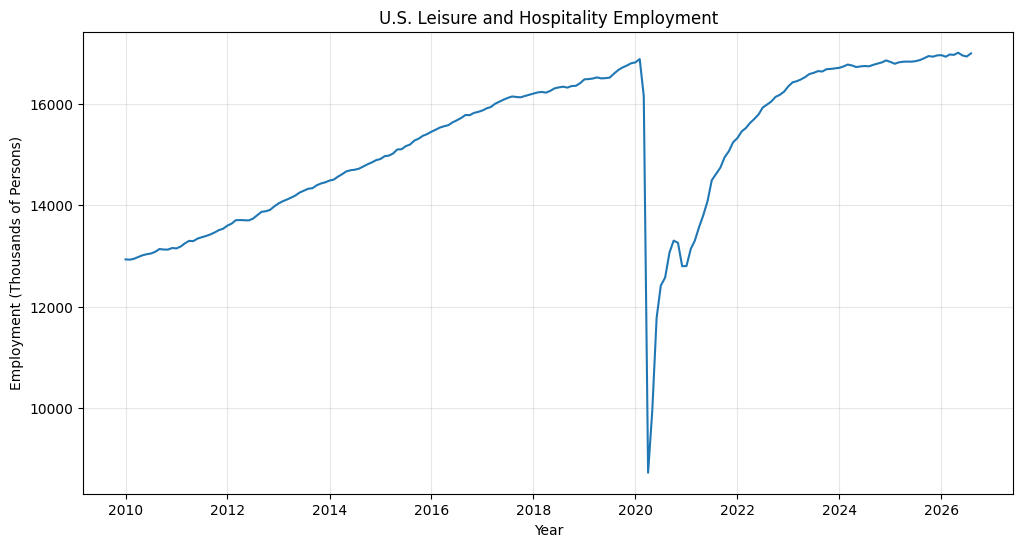

In [8]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["date"],
    df["employment"]
)

plt.title(
    "U.S. Leisure and Hospitality Employment"
)
plt.xlabel("Year")
plt.ylabel("Employment (Thousands of Persons)")
plt.grid(alpha=0.3)

plt.show()

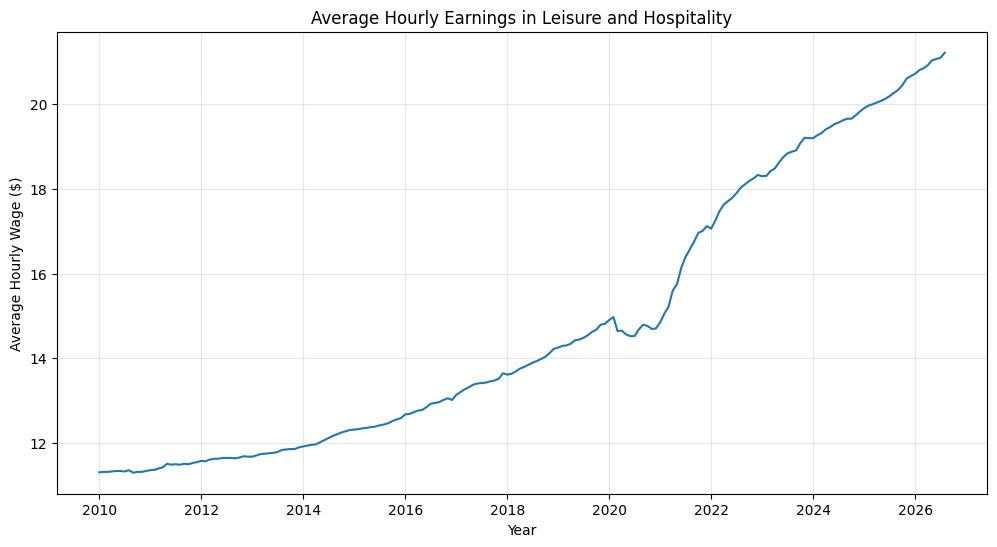

In [9]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["date"],
    df["hourly_wage"]
)

plt.title(
    "Average Hourly Earnings in Leisure and Hospitality"
)
plt.xlabel("Year")
plt.ylabel("Average Hourly Wage ($)")
plt.grid(alpha=0.3)

plt.show()

In [10]:
display(df.tail())

,date,employment,hourly_wage
195,2026-04-01,16972,20.92
196,2026-05-01,17014,21.04
197,2026-06-01,16960,21.07
198,2026-07-01,16939,21.10
199,2026-08-01,17001,21.22


# Step 2: Exploratory Analysis and Feature Engineering

## Exploratory Data Analysis and Preprocessing

Before estimating the counterfactual model, the dataset was examined for missing values,
duplicate observations, trends, unusual events, and relationships between the variables.

Because the data are monthly time-series observations, chronological ordering is preserved
during model development rather than randomly splitting observations into training and
testing sets.

The COVID-19 pandemic represents an unusual structural shock to leisure and hospitality
employment. A COVID-period indicator is therefore included as a control variable so that
the model does not incorrectly attribute the 2020 employment collapse to changes in wages.

In [11]:
# ============================================
# 5. EXPLORATORY DATA ANALYSIS
# ============================================

# Correlation between employment and hourly wages
correlation = df["employment"].corr(df["hourly_wage"])

print(f"Correlation between employment and hourly wage: {correlation:.3f}")

Correlation between employment and hourly wage: 0.637


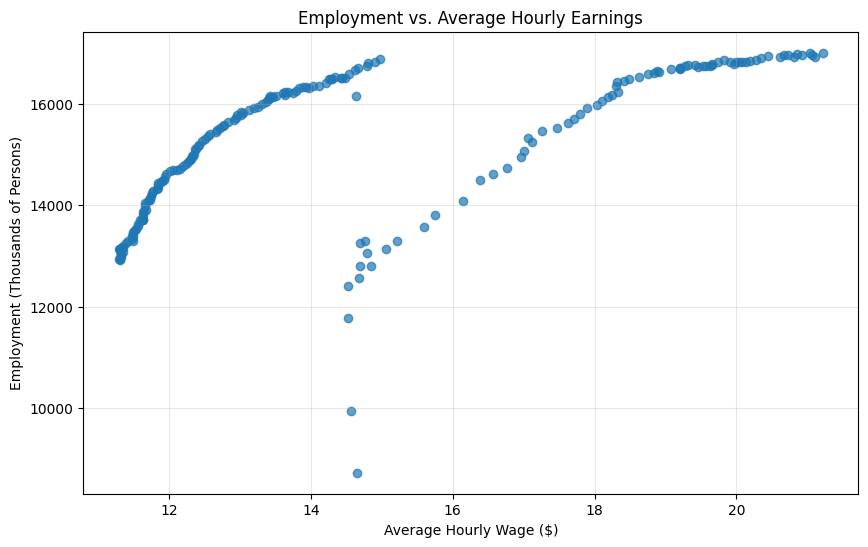

In [12]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["hourly_wage"],
    df["employment"],
    alpha=0.7
)

plt.title("Employment vs. Average Hourly Earnings")
plt.xlabel("Average Hourly Wage ($)")
plt.ylabel("Employment (Thousands of Persons)")
plt.grid(alpha=0.3)

plt.show()

In [13]:
# Create sequential monthly time trend
df["time"] = np.arange(len(df))

display(
    df[["date", "employment", "hourly_wage", "time"]].head()
)

,date,employment,hourly_wage,time
0,2010-01-01,12932,11.30,0
1,2010-02-01,12927,11.31,1
2,2010-03-01,12943,11.31,2
3,2010-04-01,12979,11.32,3
4,2010-05-01,13012,11.33,4


In [14]:
# Create COVID disruption indicator
#
# The most severe disruption to leisure and hospitality occurred beginning in March 2020.
# We use March 2020 through December 2021 as a broad pandemic disruption period.

df["covid_period"] = (
    (df["date"] >= "2020-03-01") &
    (df["date"] <= "2021-12-01")
).astype(int)

print(df["covid_period"].value_counts())

display(
    df.loc[
        (df["date"] >= "2020-01-01") &
        (df["date"] <= "2022-03-01"),
        ["date", "employment", "hourly_wage", "covid_period"]
    ].head(30)
)

covid_period
0    178
1     22
Name: count, dtype: int64


,date,employment,hourly_wage,covid_period
120,2020-01-01,16823,14.90,0
121,2020-02-01,16889,14.97,0
122,2020-03-01,16158,14.64,1
123,2020-04-01,8719,14.65,1
124,2020-05-01,9947,14.56,1
125,2020-06-01,11777,14.52,1
126,2020-07-01,12415,14.52,1
127,2020-08-01,12573,14.68,1
128,2020-09-01,13065,14.79,1
129,2020-10-01,13303,14.76,1


In [15]:
# Lag employment by one month
df["employment_lag1"] = df["employment"].shift(1)

# Remove first row because its lag is unavailable
df = df.dropna().reset_index(drop=True)

print("Dataset shape after creating lag:", df.shape)

display(df.head())

Dataset shape after creating lag: (199, 6)


,date,employment,hourly_wage,time,covid_period,employment_lag1
0,2010-02-01,12927,11.31,1,0,"12,932.00"
1,2010-03-01,12943,11.31,2,0,"12,927.00"
2,2010-04-01,12979,11.32,3,0,"12,943.00"
3,2010-05-01,13012,11.33,4,0,"12,979.00"
4,2010-06-01,13034,11.33,5,0,"13,012.00"


In [16]:
correlation_matrix = df[
    [
        "employment",
        "hourly_wage",
        "employment_lag1",
        "time",
        "covid_period"
    ]
].corr()

display(correlation_matrix.round(3))

,employment,hourly_wage,employment_lag1,time,covid_period
employment,1.00,0.63,0.93,0.65,-0.44
hourly_wage,0.63,1.00,0.63,0.96,0.07
employment_lag1,0.93,0.63,1.00,0.65,-0.42
time,0.65,0.96,0.65,1.00,0.20
covid_period,-0.44,0.07,-0.42,0.20,1.00


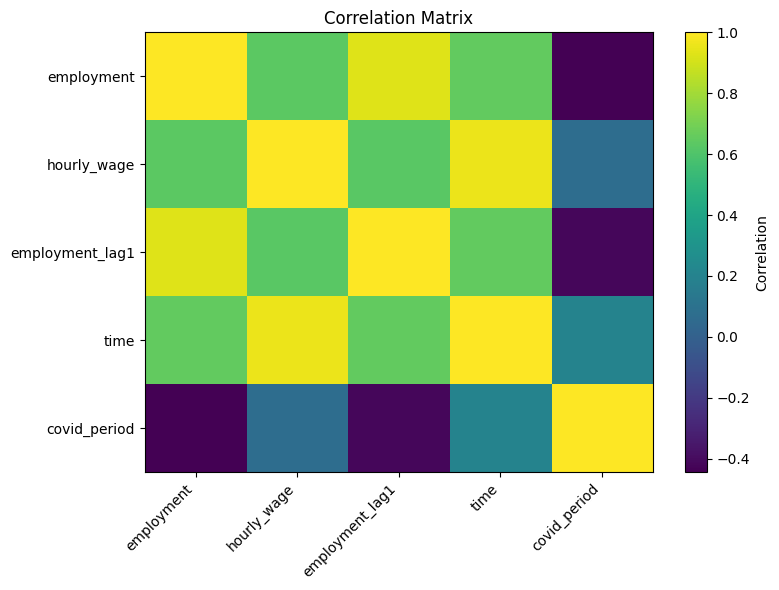

In [17]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [18]:
# ============================================
# 6. CHRONOLOGICAL TRAIN/TEST SPLIT
# ============================================

split_index = int(len(df) * 0.80)

train = df.iloc[:split_index].copy()
test = df.iloc[split_index:].copy()

print("Training observations:", len(train))
print("Testing observations:", len(test))

print("\nTraining period:")
print(train["date"].min(), "to", train["date"].max())

print("\nTesting period:")
print(test["date"].min(), "to", test["date"].max())

Training observations: 159
Testing observations: 40

Training period:
2010-02-01 00:00:00 to 2023-04-01 00:00:00

Testing period:
2023-05-01 00:00:00 to 2026-08-01 00:00:00


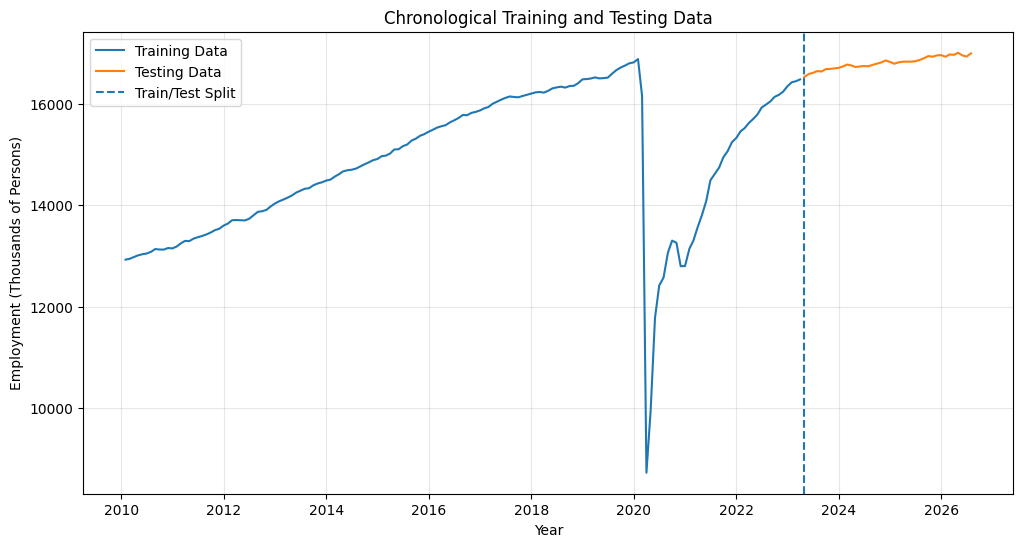

In [19]:
plt.figure(figsize=(12, 6))

plt.plot(
    train["date"],
    train["employment"],
    label="Training Data"
)

plt.plot(
    test["date"],
    test["employment"],
    label="Testing Data"
)

plt.axvline(
    test["date"].iloc[0],
    linestyle="--",
    label="Train/Test Split"
)

plt.title("Chronological Training and Testing Data")
plt.xlabel("Year")
plt.ylabel("Employment (Thousands of Persons)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Step 3: Regression Model Implementation and Evaluation

A multiple linear regression model is used to estimate employment as a function of average hourly earnings, prior-month employment, a time trend, and the COVID-19
disruption indicator.

The model is first estimated using the training period and then evaluated on the chronologically later testing period. Model performance is assessed using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R²).

Because hourly wages and the time trend are strongly correlated, multicollinearity is also examined before using the fitted model for counterfactual simulation.

In [20]:
# ============================================
# 7. DEFINE MODEL VARIABLES
# ============================================

features = [
    "hourly_wage",
    "employment_lag1",
    "time",
    "covid_period"
]

X_train = train[features]
y_train = train["employment"]

X_test = test[features]
y_test = test["employment"]

# Add intercept for statsmodels
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

print("Training feature shape:", X_train_sm.shape)
print("Testing feature shape:", X_test_sm.shape)

display(X_train_sm.head())

Training feature shape: (159, 5)
Testing feature shape: (40, 5)


,const,hourly_wage,employment_lag1,time,covid_period
0,1.00,11.31,"12,932.00",1,0
1,1.00,11.31,"12,927.00",2,0
2,1.00,11.32,"12,943.00",3,0
3,1.00,11.33,"12,979.00",4,0
4,1.00,11.33,"13,012.00",5,0


In [21]:
# ============================================
# 8. FIT MULTIPLE LINEAR REGRESSION
# ============================================

model = sm.OLS(
    y_train,
    X_train_sm
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             employment   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     216.4
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           4.04e-62
Time:                        00:42:51   Log-Likelihood:                -1227.0
No. Observations:                 159   AIC:                             2464.
Df Residuals:                     154   BIC:                             2479.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            7068.6203   1238.460     

In [22]:
# Generate predictions for training and testing sets

train_predictions = model.predict(X_train_sm)
test_predictions = model.predict(X_test_sm)

print("Predictions generated successfully.")

Predictions generated successfully.


In [23]:
# ============================================
# 9. MODEL EVALUATION
# ============================================

train_mae = mean_absolute_error(
    y_train,
    train_predictions
)

test_mae = mean_absolute_error(
    y_test,
    test_predictions
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        train_predictions
    )
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_predictions
    )
)

train_r2 = r2_score(
    y_train,
    train_predictions
)

test_r2 = r2_score(
    y_test,
    test_predictions
)

print("MODEL PERFORMANCE")
print("------------------------------")

print(f"Training MAE:  {train_mae:.2f}")
print(f"Testing MAE:   {test_mae:.2f}")

print(f"\nTraining RMSE: {train_rmse:.2f}")
print(f"Testing RMSE:  {test_rmse:.2f}")

print(f"\nTraining R²:   {train_r2:.3f}")
print(f"Testing R²:    {test_r2:.3f}")

MODEL PERFORMANCE
------------------------------
Training MAE:  173.80
Testing MAE:   122.97

Training RMSE: 543.43
Testing RMSE:  132.78

Training R²:   0.849
Testing R²:    -0.218


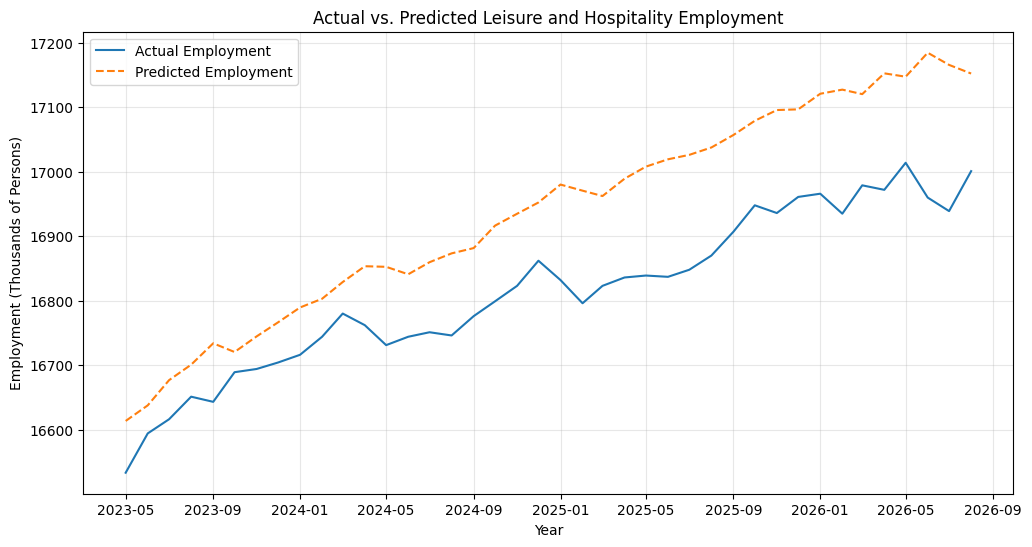

In [24]:
plt.figure(figsize=(12, 6))

plt.plot(
    test["date"],
    y_test,
    label="Actual Employment"
)

plt.plot(
    test["date"],
    test_predictions,
    label="Predicted Employment",
    linestyle="--"
)

plt.title(
    "Actual vs. Predicted Leisure and Hospitality Employment"
)

plt.xlabel("Year")
plt.ylabel("Employment (Thousands of Persons)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [25]:
test_results = test[
    ["date", "employment"]
].copy()

test_results["predicted_employment"] = test_predictions.values

test_results["residual"] = (
    test_results["employment"]
    - test_results["predicted_employment"]
)

display(test_results.head(10))

,date,employment,predicted_employment,residual
159,2023-05-01,16533,"16,613.34",-80.34
160,2023-06-01,16594,"16,637.55",-43.55
161,2023-07-01,16616,"16,676.68",-60.68
162,2023-08-01,16651,"16,700.68",-49.68
163,2023-09-01,16643,"16,733.82",-90.82
164,2023-10-01,16689,"16,720.33",-31.33
165,2023-11-01,16694,"16,744.55",-50.55
166,2023-12-01,16704,"16,766.29",-62.29
167,2024-01-01,16716,"16,789.42",-73.42
168,2024-02-01,16744,"16,802.97",-58.97


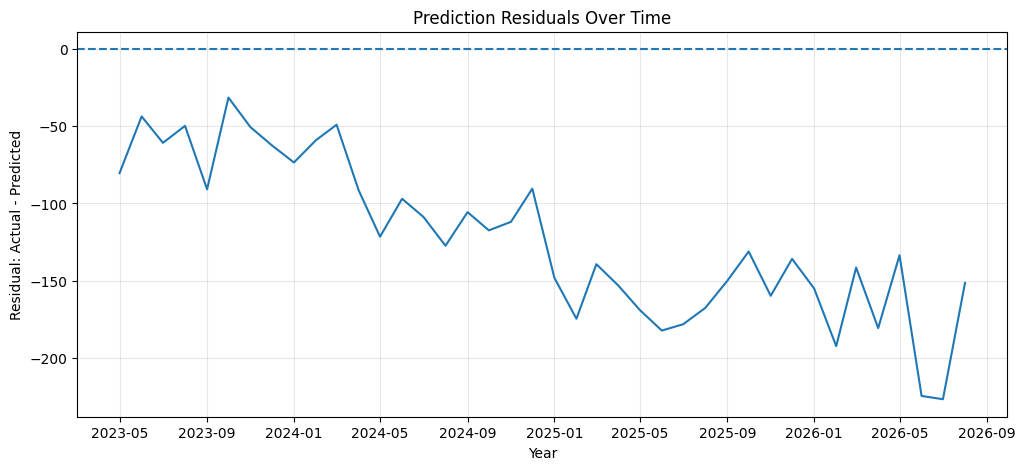

In [26]:
plt.figure(figsize=(12, 5))

plt.plot(
    test_results["date"],
    test_results["residual"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Prediction Residuals Over Time")
plt.xlabel("Year")
plt.ylabel("Residual: Actual - Predicted")

plt.grid(alpha=0.3)

plt.show()

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [28]:
# ============================================
# 10. MULTICOLLINEARITY CHECK
# ============================================

X_vif = train[
    [
        "hourly_wage",
        "employment_lag1",
        "time",
        "covid_period"
    ]
].copy()

vif_data = pd.DataFrame()

vif_data["Variable"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

display(vif_data)

,Variable,VIF
0,hourly_wage,10.45
1,employment_lag1,3.54
2,time,17.12
3,covid_period,3.60


# Step 4: Model Refinement Using Changes

The initial regression achieved a high in-sample R-squared but produced a negative R-squared on the chronological test set. In addition, hourly wages and the time trend exhibited substantial multicollinearity.

To reduce the influence of common long-term trends, the analysis is reformulated using percentage changes rather than variable levels.

The refined model estimates the relationship between monthly wage growth and monthly employment growth while controlling for lagged employment growth and the COVID-19 disruption period.

In [29]:
# ============================================
# 11. CREATE MONTHLY GROWTH VARIABLES
# ============================================

df["employment_growth"] = (
    df["employment"].pct_change() * 100
)

df["wage_growth"] = (
    df["hourly_wage"].pct_change() * 100
)

df["employment_growth_lag1"] = (
    df["employment_growth"].shift(1)
)

df_model = df.dropna().copy()

display(
    df_model[
        [
            "date",
            "employment",
            "hourly_wage",
            "employment_growth",
            "wage_growth",
            "employment_growth_lag1",
            "covid_period"
        ]
    ].head()
)

,date,employment,hourly_wage,employment_growth,wage_growth,employment_growth_lag1,covid_period
2,2010-04-01,12979,11.32,0.28,0.09,0.12,0
3,2010-05-01,13012,11.33,0.25,0.09,0.28,0
4,2010-06-01,13034,11.33,0.17,0.00,0.25,0
5,2010-07-01,13048,11.32,0.11,-0.09,0.17,0
6,2010-08-01,13081,11.35,0.25,0.27,0.11,0


In [30]:
print("Growth variable summary statistics:")

display(
    df_model[
        [
            "employment_growth",
            "wage_growth"
        ]
    ].describe()
)

Growth variable summary statistics:


,employment_growth,wage_growth
count,197.00,197.00
mean,0.23,0.32
std,3.76,0.44
min,-46.04,-2.20
25%,0.08,0.09
50%,0.24,0.26
75%,0.38,0.44
max,18.40,2.56


In [31]:
growth_corr = df_model[
    [
        "employment_growth",
        "wage_growth",
        "employment_growth_lag1",
        "covid_period"
    ]
].corr()

display(growth_corr.round(3))

,employment_growth,wage_growth,employment_growth_lag1,covid_period
employment_growth,1.00,0.06,-0.02,0.01
wage_growth,0.06,1.00,0.13,0.24
employment_growth_lag1,-0.02,0.13,1.00,0.01
covid_period,0.01,0.24,0.01,1.00


In [32]:
# ============================================
# 12. CHRONOLOGICAL SPLIT FOR REFINED MODEL
# ============================================

split_index = int(len(df_model) * 0.80)

train2 = df_model.iloc[:split_index].copy()
test2 = df_model.iloc[split_index:].copy()

print("Training observations:", len(train2))
print("Testing observations:", len(test2))

print("\nTraining period:")
print(train2["date"].min(), "to", train2["date"].max())

print("\nTesting period:")
print(test2["date"].min(), "to", test2["date"].max())

Training observations: 157
Testing observations: 40

Training period:
2010-04-01 00:00:00 to 2023-04-01 00:00:00

Testing period:
2023-05-01 00:00:00 to 2026-08-01 00:00:00


In [33]:
features2 = [
    "wage_growth",
    "employment_growth_lag1",
    "covid_period"
]

X_train2 = train2[features2]
y_train2 = train2["employment_growth"]

X_test2 = test2[features2]
y_test2 = test2["employment_growth"]

X_train2_sm = sm.add_constant(X_train2)
X_test2_sm = sm.add_constant(X_test2)

model2 = sm.OLS(
    y_train2,
    X_train2_sm
).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:      employment_growth   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.015
Method:                 Least Squares   F-statistic:                    0.2188
Date:                Mon, 28 Sep 2026   Prob (F-statistic):              0.883
Time:                        00:58:36   Log-Likelihood:                -447.82
No. Observations:                 157   AIC:                             903.6
Df Residuals:                     153   BIC:                             915.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

In [34]:
train_pred2 = model2.predict(X_train2_sm)
test_pred2 = model2.predict(X_test2_sm)

train_mae2 = mean_absolute_error(
    y_train2,
    train_pred2
)

test_mae2 = mean_absolute_error(
    y_test2,
    test_pred2
)

train_rmse2 = np.sqrt(
    mean_squared_error(
        y_train2,
        train_pred2
    )
)

test_rmse2 = np.sqrt(
    mean_squared_error(
        y_test2,
        test_pred2
    )
)

train_r2_2 = r2_score(
    y_train2,
    train_pred2
)

test_r2_2 = r2_score(
    y_test2,
    test_pred2
)

print("REFINED MODEL PERFORMANCE")
print("--------------------------------")

print(f"Training MAE:  {train_mae2:.3f}%")
print(f"Testing MAE:   {test_mae2:.3f}%")

print(f"\nTraining RMSE: {train_rmse2:.3f}%")
print(f"Testing RMSE:  {test_rmse2:.3f}%")

print(f"\nTraining R²:   {train_r2_2:.3f}")
print(f"Testing R²:    {test_r2_2:.3f}")

REFINED MODEL PERFORMANCE
--------------------------------
Training MAE:  0.834%
Testing MAE:   0.233%

Training RMSE: 4.193%
Testing RMSE:  0.286%

Training R²:   0.004
Testing R²:    -2.080


In [35]:
X_vif2 = train2[
    [
        "wage_growth",
        "employment_growth_lag1",
        "covid_period"
    ]
].copy()

vif_data2 = pd.DataFrame()

vif_data2["Variable"] = X_vif2.columns

vif_data2["VIF"] = [
    variance_inflation_factor(
        X_vif2.values,
        i
    )
    for i in range(X_vif2.shape[1])
]

display(vif_data2)

,Variable,VIF
0,wage_growth,1.09
1,employment_growth_lag1,1.02
2,covid_period,1.07


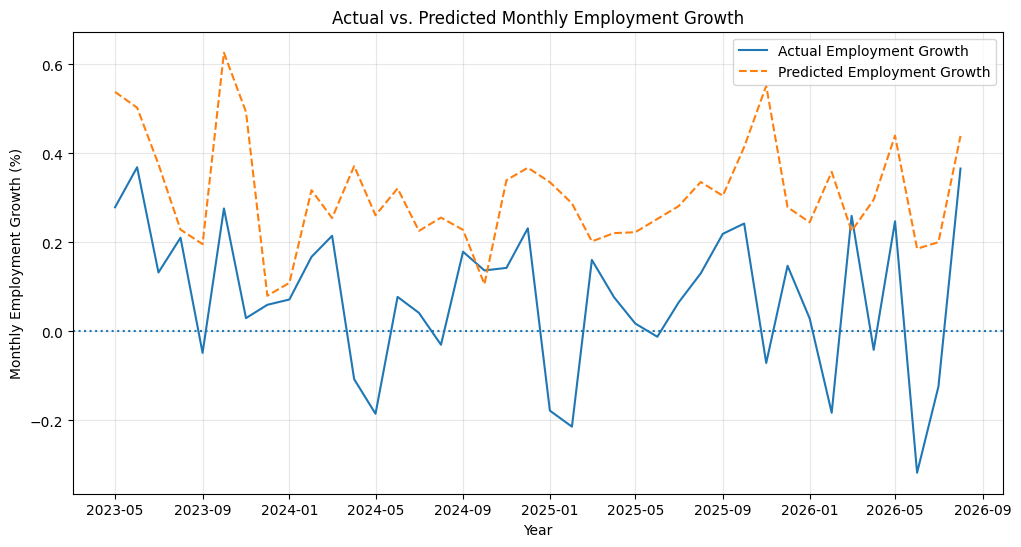

In [36]:
plt.figure(figsize=(12, 6))

plt.plot(
    test2["date"],
    y_test2,
    label="Actual Employment Growth"
)

plt.plot(
    test2["date"],
    test_pred2,
    label="Predicted Employment Growth",
    linestyle="--"
)

plt.axhline(
    y=0,
    linestyle=":"
)

plt.title(
    "Actual vs. Predicted Monthly Employment Growth"
)

plt.xlabel("Year")
plt.ylabel("Monthly Employment Growth (%)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Step 5: State-Level Panel Counterfactual Analysis

The initial national time-series models showed important limitations. The level
model experienced multicollinearity and poor out-of-sample performance, while
the growth model removed the multicollinearity but had very weak explanatory
power.

A state-level panel design is therefore used as an improved counterfactual
framework. Minimum-wage policies vary across states and years, providing
variation that is not available in a single national time series.

The panel model will compare changes across states while controlling for
persistent differences between states and common year-specific economic shocks.

In [37]:
# ============================================
# 13. DEFINE STATES FOR PANEL ANALYSIS
# ============================================

states = {
    "California": "CA",
    "New York": "NY",
    "Texas": "TX",
    "Florida": "FL",
    "Ohio": "OH",
    "Illinois": "IL",
    "Massachusetts": "MA",
    "Washington": "WA",
    "Colorado": "CO",
    "Arizona": "AZ",
    "Nevada": "NV",
    "Kentucky": "KY"
}

states

{'California': 'CA',
 'New York': 'NY',
 'Texas': 'TX',
 'Florida': 'FL',
 'Ohio': 'OH',
 'Illinois': 'IL',
 'Massachusetts': 'MA',
 'Washington': 'WA',
 'Colorado': 'CO',
 'Arizona': 'AZ',
 'Nevada': 'NV',
 'Kentucky': 'KY'}

In [38]:
# ============================================
# 14. DOWNLOAD STATE MINIMUM WAGE DATA
# ============================================

minimum_wage_frames = []

for state_name, abbreviation in states.items():

    series_id = f"STTMINWG{abbreviation}"

    url = (
        f"https://fred.stlouisfed.org/graph/"
        f"fredgraph.csv?id={series_id}"
    )

    temp = pd.read_csv(url)

    temp = temp.rename(
        columns={
            "observation_date": "date",
            series_id: "minimum_wage"
        }
    )

    temp["state"] = state_name
    temp["state_abbr"] = abbreviation

    minimum_wage_frames.append(temp)

minimum_wage = pd.concat(
    minimum_wage_frames,
    ignore_index=True
)

minimum_wage["date"] = pd.to_datetime(
    minimum_wage["date"]
)

minimum_wage["year"] = minimum_wage["date"].dt.year

display(minimum_wage.head(20))

,date,minimum_wage,state,state_abbr,year
0,1968-01-01,1.65,California,CA,1968
1,1969-01-01,1.65,California,CA,1969
2,1970-01-01,1.65,California,CA,1970
3,1971-01-01,1.65,California,CA,1971
4,1972-01-01,1.65,California,CA,1972
5,1973-01-01,1.65,California,CA,1973
6,1974-01-01,1.65,California,CA,1974
7,1975-01-01,1.65,California,CA,1975
8,1976-01-01,2.00,California,CA,1976
9,1977-01-01,2.00,California,CA,1977


In [39]:
print(minimum_wage.shape)

print(
    minimum_wage[
        ["state", "year", "minimum_wage"]
    ].groupby("state").agg(
        ["min", "max", "count"]
    )
)

(623, 5)
               year             minimum_wage            
                min   max count          min   max count
state                                                   
Arizona        2007  2026    20         6.75 15.15    20
California     1968  2026    59         1.65 16.90    59
Colorado       1968  2026    59         1.25 15.16    59
Florida        2006  2026    21         6.40 14.00    21
Illinois       1972  2026    55         1.40 15.00    55
Kentucky       1968  2026    59         0.75  7.25    59
Massachusetts  1968  2026    59         1.60 15.00    59
Nevada         1968  2026    59         1.25 12.01    59
New York       1968  2026    59         1.60 17.00    59
Ohio           1968  2026    59         1.25 11.00    59
Texas          1972  2026    55         1.40  7.25    55
Washington     1968  2026    59         1.60 17.13    59


In [40]:
minimum_wage = minimum_wage[
    (minimum_wage["year"] >= 2010) &
    (minimum_wage["year"] <= 2022)
].copy()

display(
    minimum_wage[
        ["state", "year", "minimum_wage"]
    ].head(30)
)

,state,year,minimum_wage
42,California,2010,8.00
43,California,2011,8.00
44,California,2012,8.00
45,California,2013,8.00
46,California,2014,9.00
47,California,2015,9.00
48,California,2016,10.00
49,California,2017,10.50
50,California,2018,11.00
51,California,2019,12.00


In [41]:
pivot_wage = minimum_wage.pivot(
    index="year",
    columns="state",
    values="minimum_wage"
)

display(pivot_wage)

state,Arizona,California,Colorado,Florida,Illinois,Kentucky,Massachusetts,Nevada,New York,Ohio,Texas,Washington
year,,,,,,,,,,,,
2010,7.25,8.00,7.24,7.25,8.00,7.25,8.00,7.55,7.25,7.30,7.25,8.55
2011,7.35,8.00,7.36,7.25,8.25,7.25,8.00,8.25,7.25,7.40,7.25,8.67
2012,7.65,8.00,7.64,7.67,8.25,7.25,8.00,8.25,7.25,7.70,7.25,9.04
2013,7.80,8.00,7.78,7.79,8.25,7.25,8.00,8.25,7.25,7.85,7.25,9.19
2014,7.90,9.00,8.00,7.93,8.25,7.25,8.00,8.25,8.00,7.95,7.25,9.32
2015,8.05,9.00,8.23,8.05,8.25,7.25,9.00,8.25,8.75,8.10,7.25,9.47
2016,8.05,10.00,8.31,8.05,8.25,7.25,10.00,8.25,9.00,8.10,7.25,9.47
2017,10.00,10.50,9.30,8.10,8.25,7.25,11.00,8.25,9.70,8.15,7.25,11.00
2018,10.50,11.00,10.20,8.25,8.25,7.25,11.00,8.25,10.40,8.30,7.25,11.50


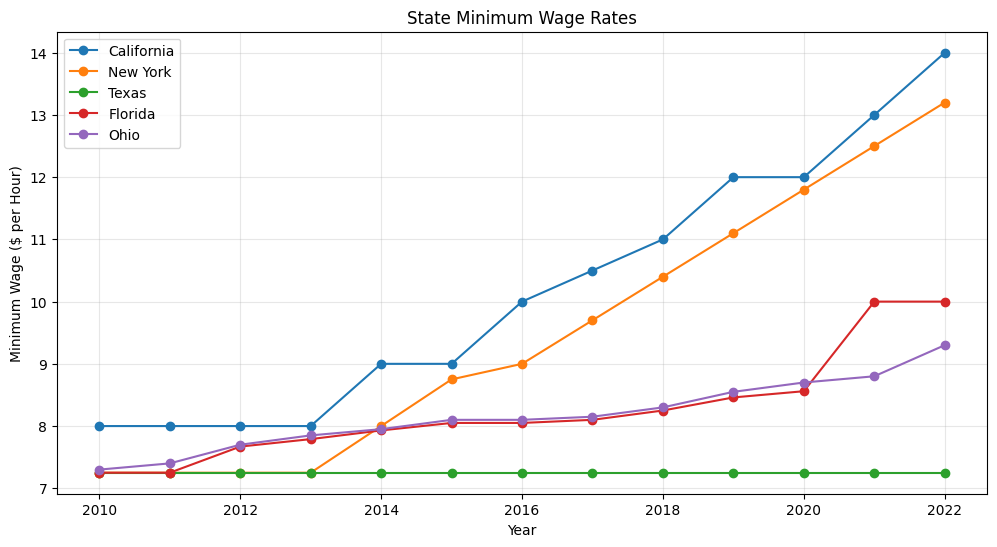

In [42]:
plt.figure(figsize=(12, 6))

for state in [
    "California",
    "New York",
    "Texas",
    "Florida",
    "Ohio"
]:
    state_data = minimum_wage[
        minimum_wage["state"] == state
    ]

    plt.plot(
        state_data["year"],
        state_data["minimum_wage"],
        marker="o",
        label=state
    )

plt.title("State Minimum Wage Rates")
plt.xlabel("Year")
plt.ylabel("Minimum Wage ($ per Hour)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [43]:
print("Missing values:")
print(minimum_wage.isnull().sum())

print("\nObservations per state:")
print(
    minimum_wage.groupby("state").size()
)

Missing values:
date            0
minimum_wage    0
state           0
state_abbr      0
year            0
dtype: int64

Observations per state:
state
Arizona          13
California       13
Colorado         13
Florida          13
Illinois         13
Kentucky         13
Massachusetts    13
Nevada           13
New York         13
Ohio             13
Texas            13
Washington       13
dtype: int64


# Step 6: State Leisure and Hospitality Employment

To evaluate the economic outcome associated with minimum-wage differences,
state-level leisure and hospitality employment is added to the panel dataset.

Monthly employment observations are converted to annual averages so that their
frequency matches the annual state minimum-wage data.

Employment growth is then calculated within each state and used as the primary
economic outcome in the panel regression.

In [46]:
# ============================================
# 15. DOWNLOAD STATE LEISURE & HOSPITALITY EMPLOYMENT
# ============================================

# State-level Leisure and Hospitality employment series
# Monthly, seasonally adjusted, thousands of persons

employment_series = {
    "California": "CALEIH",
    "New York": "NYLEIH",
    "Texas": "TXLEIH",
    "Florida": "FLLEIH",
    "Ohio": "OHLEIH",
    "Illinois": "ILLEIH",
    "Massachusetts": "MALEIH",
    "Washington": "WALEIH",
    "Colorado": "COLEIH",
    "Arizona": "AZLEIH",
    "Nevada": "NVLEIH",
    "Kentucky": "KYLEIH"
}

employment_frames = []

for state_name, series_id in employment_series.items():

    url = (
        f"https://fred.stlouisfed.org/graph/"
        f"fredgraph.csv?id={series_id}"
    )

    temp = pd.read_csv(url)

    temp = temp.rename(
        columns={
            "observation_date": "date",
            series_id: "employment"
        }
    )

    temp["state"] = state_name
    temp["state_abbr"] = states[state_name]

    employment_frames.append(temp)

employment_panel = pd.concat(
    employment_frames,
    ignore_index=True
)

employment_panel["date"] = pd.to_datetime(
    employment_panel["date"]
)

display(employment_panel.head())

print("Shape:", employment_panel.shape)
print("\nColumns:")
print(employment_panel.columns)

,date,employment,state,state_abbr
0,1990-01-01,"1,107.60",California,CA
1,1990-02-01,"1,106.50",California,CA
2,1990-03-01,"1,107.50",California,CA
3,1990-04-01,"1,105.90",California,CA
4,1990-05-01,"1,098.20",California,CA


Shape: (5280, 4)

Columns:
Index(['date', 'employment', 'state', 'state_abbr'], dtype='object')


In [49]:
# Convert monthly employment data to year
employment_panel["year"] = employment_panel["date"].dt.year

# Keep same study period
employment_panel = employment_panel[
    (employment_panel["year"] >= 2010) &
    (employment_panel["year"] <= 2022)
]

# Annual average employment by state
annual_employment = (
    employment_panel
    .groupby(["state", "state_abbr", "year"])["employment"]
    .mean()
    .reset_index()
)

display(annual_employment.head())

,state,state_abbr,year,employment
0,Arizona,AZ,2010,253.91
1,Arizona,AZ,2011,259.26
2,Arizona,AZ,2012,266.87
3,Arizona,AZ,2013,275.86
4,Arizona,AZ,2014,286.52


In [50]:
annual_employment = annual_employment.sort_values(
    ["state", "year"]
)

annual_employment["employment_growth"] = (
    annual_employment
    .groupby("state")["employment"]
    .pct_change() * 100
)

display(
    annual_employment[
        [
            "state",
            "year",
            "employment",
            "employment_growth"
        ]
    ].head(20)
)

,state,year,employment,employment_growth
0,Arizona,2010,253.91,NaN
1,Arizona,2011,259.26,2.11
2,Arizona,2012,266.87,2.93
3,Arizona,2013,275.86,3.37
4,Arizona,2014,286.52,3.86
5,Arizona,2015,299.02,4.37
6,Arizona,2016,309.66,3.56
7,Arizona,2017,319.88,3.30
8,Arizona,2018,326.16,1.96
9,Arizona,2019,331.85,1.75


In [51]:
panel = pd.merge(
    minimum_wage,
    annual_employment,
    on=["state", "state_abbr", "year"],
    how="inner"
)

display(panel.head())

print("Panel shape:", panel.shape)

print("\nMissing values:")
print(panel.isnull().sum())

,date,minimum_wage,state,state_abbr,year,employment,employment_growth
0,2010-01-01,8.00,California,CA,2010,"1,500.58",NaN
1,2011-01-01,8.00,California,CA,2011,"1,534.81",2.28
2,2012-01-01,8.00,California,CA,2012,"1,597.88",4.11
3,2013-01-01,8.00,California,CA,2013,"1,675.62",4.87
4,2014-01-01,9.00,California,CA,2014,"1,757.12",4.86


Panel shape: (156, 7)

Missing values:
date                  0
minimum_wage          0
state                 0
state_abbr            0
year                  0
employment            0
employment_growth    12
dtype: int64


In [52]:
panel_model = panel.dropna(
    subset=["employment_growth"]
).copy()

print("Model observations:", len(panel_model))

print(
    panel_model.groupby("state").size()
)

Model observations: 144
state
Arizona          12
California       12
Colorado         12
Florida          12
Illinois         12
Kentucky         12
Massachusetts    12
Nevada           12
New York         12
Ohio             12
Texas            12
Washington       12
dtype: int64


# Step 7: Fixed-Effects Panel Regression

A two-way fixed-effects regression is used to estimate the relationship between
state minimum wages and annual leisure and hospitality employment growth.

State fixed effects control for persistent differences among states that do not
change substantially over time, such as geography, industrial composition, and
long-run institutional characteristics.

Year fixed effects control for economic shocks shared across states in a given
year, including national business-cycle conditions and the COVID-19 pandemic.

The coefficient on minimum wage therefore reflects the within-state association
between changes in minimum wage and employment growth after accounting for
state-specific and year-specific effects.

In [53]:
# ============================================
# 16. TWO-WAY FIXED-EFFECTS PANEL MODEL
# ============================================

import statsmodels.formula.api as smf

fe_model = smf.ols(
    formula="""
        employment_growth
        ~ minimum_wage
        + C(state)
        + C(year)
    """,
    data=panel_model
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": panel_model["state"]
    }
)

print(fe_model.summary())

                            OLS Regression Results                            
Dep. Variable:      employment_growth   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                     768.8
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           3.19e-14
Time:                        01:16:11   Log-Likelihood:                -310.71
No. Observations:                 144   AIC:                             669.4
Df Residuals:                     120   BIC:                             740.7
Df Model:                          23                                         
Covariance Type:              cluster                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:1988: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 23, but rank is 11
  res = self.wald_test(


In [54]:
# Extract key minimum-wage coefficient information

mw_coef = fe_model.params["minimum_wage"]
mw_pvalue = fe_model.pvalues["minimum_wage"]
mw_ci = fe_model.conf_int().loc["minimum_wage"]

print("MINIMUM WAGE EFFECT")
print("--------------------------------")

print(f"Coefficient: {mw_coef:.4f}")
print(f"P-value:     {mw_pvalue:.4f}")

print(
    f"95% CI:      "
    f"[{mw_ci.iloc[0]:.4f}, {mw_ci.iloc[1]:.4f}]"
)

MINIMUM WAGE EFFECT
--------------------------------
Coefficient: 0.1056
P-value:     0.3348
95% CI:      [-0.1090, 0.3201]


In [55]:
print(f"R-squared:          {fe_model.rsquared:.3f}")
print(f"Adjusted R-squared: {fe_model.rsquared_adj:.3f}")
print(f"Number of observations: {int(fe_model.nobs)}")

R-squared:          0.942
Adjusted R-squared: 0.931
Number of observations: 144


# Step 8: Counterfactual Policy Simulation

Counterfactual scenarios are generated by increasing each observed state minimum
wage by 5%, 10%, 15%, and 20%, while holding the state's identity and year
constant.

The fitted fixed-effects model is then used to estimate annual leisure and
hospitality employment growth under each hypothetical policy scenario.

The difference between each counterfactual prediction and the baseline model
prediction represents the estimated model-based effect of the hypothetical
minimum-wage change.

In [56]:
# ============================================
# 17. CREATE COUNTERFACTUAL SCENARIOS
# ============================================

counterfactual = panel_model.copy()

# Baseline prediction
counterfactual["baseline_prediction"] = (
    fe_model.predict(counterfactual)
)

scenarios = [5, 10, 15, 20]

for increase in scenarios:

    scenario_data = panel_model.copy()

    scenario_data["minimum_wage"] = (
        scenario_data["minimum_wage"]
        * (1 + increase / 100)
    )

    counterfactual[
        f"prediction_{increase}pct"
    ] = fe_model.predict(scenario_data)

    counterfactual[
        f"effect_{increase}pct"
    ] = (
        counterfactual[f"prediction_{increase}pct"]
        - counterfactual["baseline_prediction"]
    )

display(
    counterfactual[
        [
            "state",
            "year",
            "minimum_wage",
            "employment_growth",
            "baseline_prediction",
            "prediction_5pct",
            "prediction_10pct",
            "prediction_15pct",
            "prediction_20pct"
        ]
    ].head(20)
)

,state,year,minimum_wage,employment_growth,baseline_prediction,prediction_5pct,prediction_10pct,prediction_15pct,prediction_20pct
1,California,2011,8.00,2.28,2.92,2.96,3.00,3.05,3.09
2,California,2012,8.00,4.11,3.74,3.78,3.82,3.86,3.90
3,California,2013,8.00,4.87,3.95,3.99,4.03,4.08,4.12
4,California,2014,9.00,4.86,3.91,3.96,4.00,4.05,4.10
5,California,2015,9.00,4.07,4.02,4.07,4.12,4.16,4.21
6,California,2016,10.00,3.98,3.80,3.86,3.91,3.96,4.02
7,California,2017,10.50,2.68,2.97,3.02,3.08,3.13,3.19
8,California,2018,11.00,2.02,2.37,2.42,2.48,2.54,2.60
9,California,2019,12.00,2.14,2.24,2.30,2.36,2.43,2.49
10,California,2020,12.00,-27.19,-22.72,-22.65,-22.59,-22.53,-22.46


In [57]:
scenario_summary = pd.DataFrame({
    "Scenario": [
        "5% increase",
        "10% increase",
        "15% increase",
        "20% increase"
    ],

    "Average Predicted Effect on Employment Growth (%)": [
        counterfactual["effect_5pct"].mean(),
        counterfactual["effect_10pct"].mean(),
        counterfactual["effect_15pct"].mean(),
        counterfactual["effect_20pct"].mean()
    ]
})

display(scenario_summary)

,Scenario,Average Predicted Effect on Employment Growth (%)
0,5% increase,0.05
1,10% increase,0.10
2,15% increase,0.14
3,20% increase,0.19


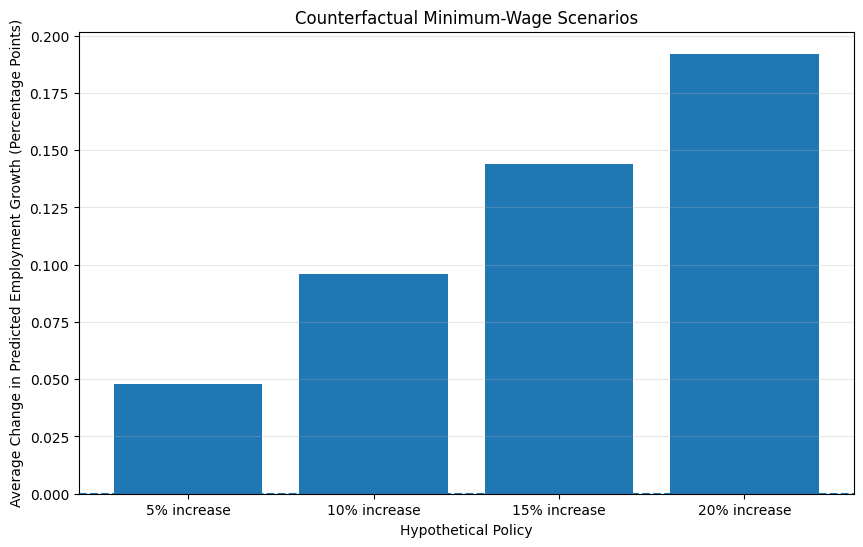

In [58]:
plt.figure(figsize=(10, 6))

plt.bar(
    scenario_summary["Scenario"],
    scenario_summary[
        "Average Predicted Effect on Employment Growth (%)"
    ]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "Counterfactual Minimum-Wage Scenarios"
)

plt.xlabel("Hypothetical Policy")
plt.ylabel(
    "Average Change in Predicted "
    "Employment Growth (Percentage Points)"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

# Step 9: Add a direct comparison of actual vs predicted values

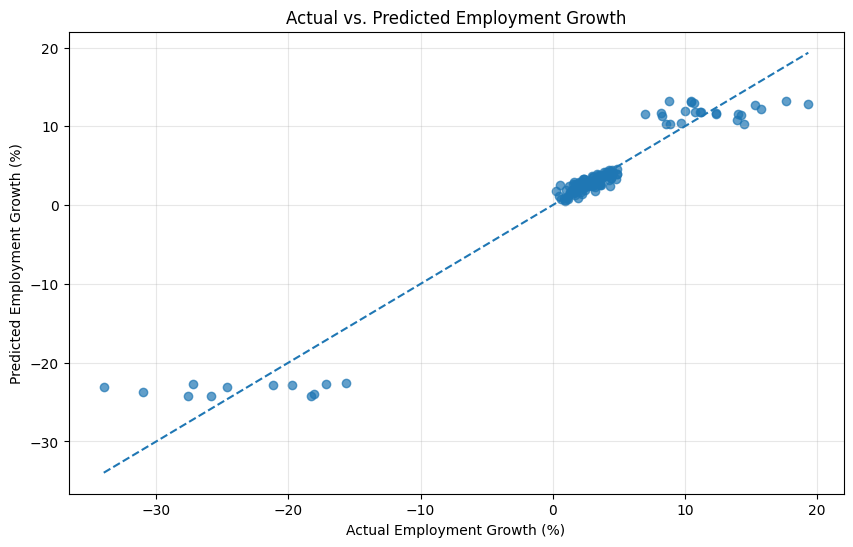

In [59]:
# ============================================
# 18. ACTUAL VS FITTED EMPLOYMENT GROWTH
# ============================================

panel_model["fitted_growth"] = fe_model.predict(
    panel_model
)

plt.figure(figsize=(10, 6))

plt.scatter(
    panel_model["employment_growth"],
    panel_model["fitted_growth"],
    alpha=0.7
)

min_val = min(
    panel_model["employment_growth"].min(),
    panel_model["fitted_growth"].min()
)

max_val = max(
    panel_model["employment_growth"].max(),
    panel_model["fitted_growth"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual Employment Growth (%)")
plt.ylabel("Predicted Employment Growth (%)")

plt.title(
    "Actual vs. Predicted Employment Growth"
)

plt.grid(alpha=0.3)

plt.show()

# Step 10: Add uncertainty to the counterfactual interpretation

In [60]:
# ============================================
# 19. COUNTERFACTUAL UNCERTAINTY RANGE
# ============================================

avg_min_wage = panel_model["minimum_wage"].mean()

coef_low = mw_ci.iloc[0]
coef_high = mw_ci.iloc[1]

uncertainty_results = []

for increase in scenarios:

    wage_change = (
        avg_min_wage * increase / 100
    )

    point_effect = (
        mw_coef * wage_change
    )

    lower_effect = (
        coef_low * wage_change
    )

    upper_effect = (
        coef_high * wage_change
    )

    uncertainty_results.append({
        "Scenario": f"{increase}% increase",
        "Point Estimate": point_effect,
        "Lower 95% Bound": lower_effect,
        "Upper 95% Bound": upper_effect
    })

uncertainty_df = pd.DataFrame(
    uncertainty_results
)

display(uncertainty_df)

,Scenario,Point Estimate,Lower 95% Bound,Upper 95% Bound
0,5% increase,0.05,-0.05,0.15
1,10% increase,0.10,-0.10,0.29
2,15% increase,0.14,-0.15,0.44
3,20% increase,0.19,-0.20,0.58


# Step 11: Add a robustness model excluding COVID years

In [61]:
# ============================================
# 20. ROBUSTNESS CHECK: PRE-COVID PERIOD
# ============================================

pre_covid = panel_model[
    panel_model["year"] <= 2019
].copy()

pre_covid_model = smf.ols(
    formula="""
        employment_growth
        ~ minimum_wage
        + C(state)
        + C(year)
    """,
    data=pre_covid
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": pre_covid["state"]
    }
)

print(pre_covid_model.summary())

print("\nPRE-COVID MINIMUM WAGE EFFECT")
print("--------------------------------")

print(
    "Coefficient:",
    round(
        pre_covid_model.params["minimum_wage"],
        4
    )
)

print(
    "P-value:",
    round(
        pre_covid_model.pvalues["minimum_wage"],
        4
    )
)

                            OLS Regression Results                            
Dep. Variable:      employment_growth   R-squared:                       0.718
Model:                            OLS   Adj. R-squared:                  0.653
Method:                 Least Squares   F-statistic:                     719.9
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           6.21e-14
Time:                        01:28:33   Log-Likelihood:                -99.146
No. Observations:                 108   AIC:                             240.3
Df Residuals:                      87   BIC:                             296.6
Df Model:                          20                                         
Covariance Type:              cluster                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:1988: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 20, but rank is 9
  res = self.wald_test(


# Conclusion

This project evaluated the potential effect of hypothetical state minimum-wage
increases on leisure and hospitality employment growth using a two-way
fixed-effects panel regression.

The primary model, based on 144 state-year observations from 12 states between
2011 and 2022, estimated a small positive association between the minimum wage
and annual employment growth. A $1 increase in the minimum wage was associated
with approximately a 0.106 percentage-point increase in employment growth.
However, this estimate was not statistically significant (p = 0.335), and its
95% confidence interval included both negative and positive effects.

Counterfactual simulations of 5%, 10%, 15%, and 20% minimum-wage increases
produced relatively small positive point estimates. For example, a hypothetical
10% increase produced an average predicted employment-growth change of
approximately 0.10 percentage points. However, the uncertainty interval for
this scenario ranged from approximately -0.10 to +0.29 percentage points,
indicating that the true effect could plausibly be negative, negligible, or
positive.

A robustness analysis restricted to the pre-COVID period produced a negative
minimum-wage coefficient of approximately -0.154, compared with +0.106 in the
full sample. The pre-COVID estimate was also not statistically significant
(p = 0.313). The reversal in sign demonstrates that the estimated relationship
is sensitive to the time period examined.

Overall, the analysis does not provide statistically reliable evidence that
the hypothetical minimum-wage increases would either increase or decrease
leisure and hospitality employment growth. Instead, the results demonstrate
the uncertainty inherent in counterfactual economic analysis and highlight the
importance of model specification, time-period selection, and sensitivity
analysis when evaluating policy effects.

The counterfactual projections should therefore be interpreted as
model-dependent scenarios rather than definitive causal estimates.